# Project: Patient Readmission Risk Prediction

## Notebook 1: EDA and Data Audit

This notebook is the starting point of the patient readmission prediction project.

The main goal here is to understand the dataset properly before building any model.

In this notebook, I will:
- load the dataset
- inspect the columns and data types
- check missing values and duplicates
- review the target variable
- identify possible data leakage
- do some basic exploratory analysis

This step is important because a healthcare prediction project can easily go wrong if the data is not checked carefully first.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## Load the dataset

First, I will load the raw dataset and make sure it is readable.

In [3]:
df = pd.read_csv("../data/raw/Healthcare Data Analysis for readmission.csv")
print("Dataset loaded successfully.")

Dataset loaded successfully.


In [4]:
df.head()

,hospital_name,Admission_date,hospital_id,hospital_beds_available,occupied_beds,hospital_ward,patient_id,patient_gender,patient_age,patient_race,patient_sat_score,patient_first_initial,patient_last_name,patient_waittime,department_referral,time_slot,doctor_id,doctor_name,doctor_specialty,patient_assigned_doctor,patient_checkin_date,patient_checkout_date,patient_disease,patient_length_of_stay,discharge_status,readmission
0,The Johns Hopkins Hospital,30-01-2024,3946,260,90,Maternity,1421,Female,48,Asian,490,t,Rogers,120,Urology or Nephrology,02:34:00 PM,1725,Justin Morris,Rheumatology,False,14-07-2024,19-07-2024,Anxiety Disorders,6,Deceased,1
1,The Johns Hopkins Hospital,20-03-2022,7147,250,90,ICU,4922,Male,40,Black,1210,i,Spencer,60,Neurology,04:07:00 PM,7510,Latoya Moss,Pulmonology or Allergy and Immunology,False,19-07-2024,07/07/2024,Urinary Tract Infection (UTI),2,Deceased,1
2,The Johns Hopkins Hospital,13-07-2021,4174,350,220,Pediatrics,9804,Female,74,Black,920,Y,Hall,120,Neurology,07:16:00 PM,7137,Michael Allen,Neurology,False,20-07-2024,29-06-2024,Hypertension (High Blood Pressure),17,Recovered,0
3,The Johns Hopkins Hospital,26-01-2021,2466,190,350,Pediatrics,5622,Male,82,Hispanic,1010,s,Rodriguez,75,Gastroenterology,07:27:00 AM,8801,Rebecca Mccullough,Cardiology,False,25-06-2024,16-07-2024,Arthritis,28,Recovered,0
4,The Johns Hopkins Hospital,06/02/2024,3014,220,390,Surgery,3314,Male,62,Hispanic,570,o,Duffy,90,Dermatology,01:54:00 PM,3588,John Giles,Rheumatology,False,21-07-2024,19-07-2024,Cancer,16,Transferred,1


## Basic shape of the dataset

Before doing anything else, I want to check how many rows and columns the dataset has.

In [5]:
print("Dataset shape:", df.shape)

Dataset shape: (10000, 26)


## Column names

Now I want to inspect all column names properly so I can understand what information is available and what may or may not be useful for prediction.

In [6]:
print(df.columns.tolist())

['hospital_name', 'Admission_date', 'hospital_id', 'hospital_beds_available', 'occupied_beds', 'hospital_ward', 'patient_id', 'patient_gender', 'patient_age', 'patient_race', 'patient_sat_score', 'patient_first_initial', 'patient_last_name', 'patient_waittime', 'department_referral', 'time_slot', 'doctor_id', 'doctor_name', 'doctor_specialty', 'patient_assigned_doctor', 'patient_checkin_date', 'patient_checkout_date', 'patient_disease', 'patient_length_of_stay', 'discharge_status', 'readmission']


## Dataset info

This gives a quick overview of data types and missing values.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   hospital_name            10000 non-null  object
 1   Admission_date           10000 non-null  object
 2   hospital_id              10000 non-null  int64 
 3   hospital_beds_available  10000 non-null  int64 
 4   occupied_beds            10000 non-null  int64 
 5   hospital_ward            10000 non-null  object
 6   patient_id               10000 non-null  int64 
 7   patient_gender           10000 non-null  object
 8   patient_age              10000 non-null  int64 
 9   patient_race             10000 non-null  object
 10  patient_sat_score        10000 non-null  int64 
 11  patient_first_initial    10000 non-null  object
 12  patient_last_name        10000 non-null  object
 13  patient_waittime         10000 non-null  int64 
 14  department_referral      10000 non-null

## Missing values

Healthcare data often has missing fields, so this is one of the first things I need to check.

In [8]:
df.isnull().sum()

hospital_name              0
Admission_date             0
hospital_id                0
hospital_beds_available    0
occupied_beds              0
hospital_ward              0
patient_id                 0
patient_gender             0
patient_age                0
patient_race               0
patient_sat_score          0
patient_first_initial      0
patient_last_name          0
patient_waittime           0
department_referral        0
time_slot                  0
doctor_id                  0
doctor_name                0
doctor_specialty           0
patient_assigned_doctor    0
patient_checkin_date       0
patient_checkout_date      0
patient_disease            0
patient_length_of_stay     0
discharge_status           0
readmission                0
dtype: int64

## Duplicate rows

If duplicate rows exist, they can distort the analysis and model performance.

In [9]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## Clean the column names

I want to make the column names easier to work with by converting them to lowercase and replacing spaces with underscores.

In [10]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
print(df.columns.tolist())

['hospital_name', 'admission_date', 'hospital_id', 'hospital_beds_available', 'occupied_beds', 'hospital_ward', 'patient_id', 'patient_gender', 'patient_age', 'patient_race', 'patient_sat_score', 'patient_first_initial', 'patient_last_name', 'patient_waittime', 'department_referral', 'time_slot', 'doctor_id', 'doctor_name', 'doctor_specialty', 'patient_assigned_doctor', 'patient_checkin_date', 'patient_checkout_date', 'patient_disease', 'patient_length_of_stay', 'discharge_status', 'readmission']


## Preview the cleaned dataset

Now I will look at the first few rows again after standardizing the column names.

In [11]:
df.head()

,hospital_name,admission_date,hospital_id,hospital_beds_available,occupied_beds,hospital_ward,patient_id,patient_gender,patient_age,patient_race,patient_sat_score,patient_first_initial,patient_last_name,patient_waittime,department_referral,time_slot,doctor_id,doctor_name,doctor_specialty,patient_assigned_doctor,patient_checkin_date,patient_checkout_date,patient_disease,patient_length_of_stay,discharge_status,readmission
0,The Johns Hopkins Hospital,30-01-2024,3946,260,90,Maternity,1421,Female,48,Asian,490,t,Rogers,120,Urology or Nephrology,02:34:00 PM,1725,Justin Morris,Rheumatology,False,14-07-2024,19-07-2024,Anxiety Disorders,6,Deceased,1
1,The Johns Hopkins Hospital,20-03-2022,7147,250,90,ICU,4922,Male,40,Black,1210,i,Spencer,60,Neurology,04:07:00 PM,7510,Latoya Moss,Pulmonology or Allergy and Immunology,False,19-07-2024,07/07/2024,Urinary Tract Infection (UTI),2,Deceased,1
2,The Johns Hopkins Hospital,13-07-2021,4174,350,220,Pediatrics,9804,Female,74,Black,920,Y,Hall,120,Neurology,07:16:00 PM,7137,Michael Allen,Neurology,False,20-07-2024,29-06-2024,Hypertension (High Blood Pressure),17,Recovered,0
3,The Johns Hopkins Hospital,26-01-2021,2466,190,350,Pediatrics,5622,Male,82,Hispanic,1010,s,Rodriguez,75,Gastroenterology,07:27:00 AM,8801,Rebecca Mccullough,Cardiology,False,25-06-2024,16-07-2024,Arthritis,28,Recovered,0
4,The Johns Hopkins Hospital,06/02/2024,3014,220,390,Surgery,3314,Male,62,Hispanic,570,o,Duffy,90,Dermatology,01:54:00 PM,3588,John Giles,Rheumatology,False,21-07-2024,19-07-2024,Cancer,16,Transferred,1


## Target variable check

The target for this project is `readmission`.

Before modelling, I need to understand:
- what values it contains
- whether the classes are balanced or not

In [12]:
print(df["readmission"].value_counts(dropna=False))

readmission
0    5858
1    4142
Name: count, dtype: int64


In [24]:
print("Readmission dtype:", df["readmission"].dtype)
print("Unique target values:", df["readmission"].unique())

Readmission dtype: int64
Unique target values: [1 0]


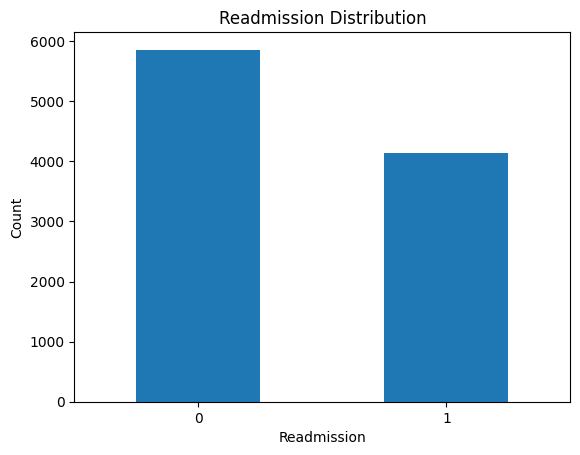

In [13]:
df["readmission"].value_counts().plot(kind="bar")
plt.title("Readmission Distribution")
plt.xlabel("Readmission")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

## Quick review of possible feature types

At this stage, I want to roughly separate the columns into:
- identifiers
- date columns
- categorical variables
- numeric variables
- target

In [14]:
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumeric columns:")
print(numeric_cols)

Categorical columns:
['hospital_name', 'admission_date', 'hospital_ward', 'patient_gender', 'patient_race', 'patient_first_initial', 'patient_last_name', 'department_referral', 'time_slot', 'doctor_name', 'doctor_specialty', 'patient_checkin_date', 'patient_checkout_date', 'patient_disease', 'discharge_status']

Numeric columns:
['hospital_id', 'hospital_beds_available', 'occupied_beds', 'patient_id', 'patient_age', 'patient_sat_score', 'patient_waittime', 'doctor_id', 'patient_length_of_stay', 'readmission']


## First leakage review

Not every column should be used for prediction.

Some columns are identifiers or personal details and should be dropped later.
Some date columns may need feature engineering.
Some columns may introduce leakage if they would not realistically be available at prediction time.

For this project, the intended use case is:
**predict readmission risk at discharge time**

In [15]:
possible_drop_cols = [
    "hospital_name",
    "hospital_id",
    "patient_id",
    "patient_first_initial",
    "patient_last_name",
    "doctor_id",
    "doctor_name"
]

print("Columns that will likely be dropped later:")
print(possible_drop_cols)

Columns that will likely be dropped later:
['hospital_name', 'hospital_id', 'patient_id', 'patient_first_initial', 'patient_last_name', 'doctor_id', 'doctor_name']


## Notes on likely useful features

These columns look potentially useful for the prediction task:
- hospital_beds_available
- occupied_beds
- hospital_ward
- patient_gender
- patient_age
- patient_race
- patient_sat_score
- patient_waittime
- department_referral
- time_slot
- doctor_specialty
- patient_disease
- patient_length_of_stay
- discharge_status

These will be reviewed more carefully in the next notebook.

## Date columns

The raw date columns should not be used directly in modelling.

Instead, I will inspect them first and later convert them into more useful features such as:
- month
- weekday
- stay duration
- timing patterns

In [16]:
date_cols = ["admission_date", "patient_checkin_date", "patient_checkout_date"]

for col in date_cols:
    if col in df.columns:
        print(f"{col} sample values:")
        print(df[col].head())
        print()

admission_date sample values:
0    30-01-2024
1    20-03-2022
2    13-07-2021
3    26-01-2021
4    06/02/2024
Name: admission_date, dtype: object

patient_checkin_date sample values:
0    14-07-2024
1    19-07-2024
2    20-07-2024
3    25-06-2024
4    21-07-2024
Name: patient_checkin_date, dtype: object

patient_checkout_date sample values:
0    19-07-2024
1    07/07/2024
2    29-06-2024
3    16-07-2024
4    19-07-2024
Name: patient_checkout_date, dtype: object



## Note on date consistency

From the sample values, the date columns appear to use mixed formats.

For example, some values use `dd-mm-yyyy` while others use `dd/mm/yyyy`.

This will need careful handling in the preprocessing stage to avoid incorrect date parsing or missing values during conversion.

## Basic exploration of a few important variables

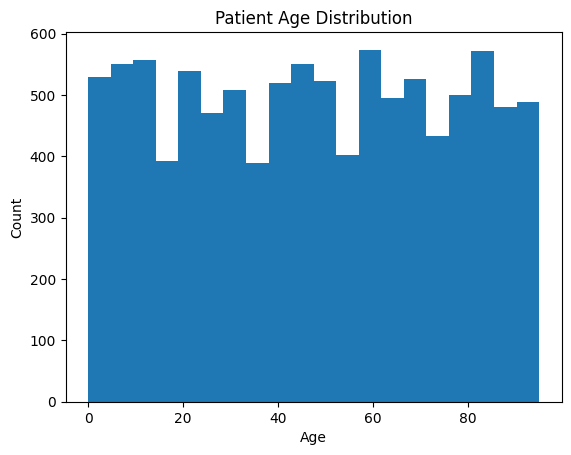

In [17]:
df["patient_age"].plot(kind="hist", bins=20)
plt.title("Patient Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

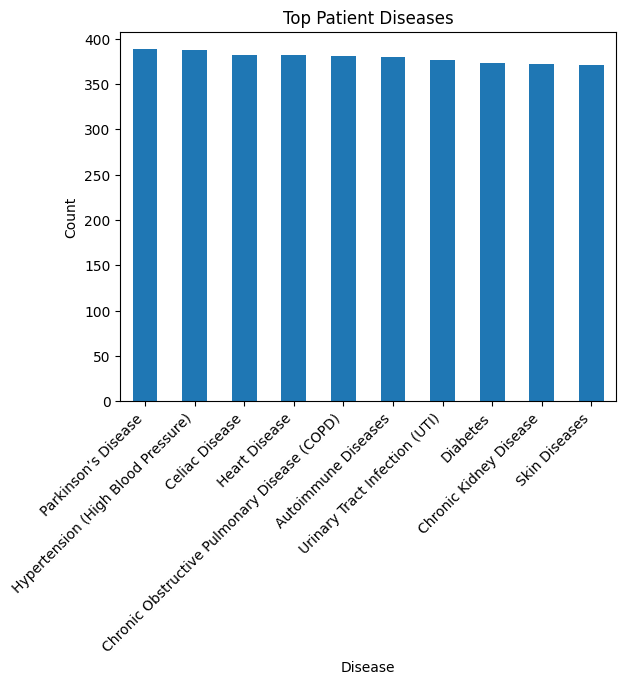

In [18]:
df["patient_disease"].value_counts().head(10).plot(kind="bar")
plt.title("Top Patient Diseases")
plt.xlabel("Disease")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.show()

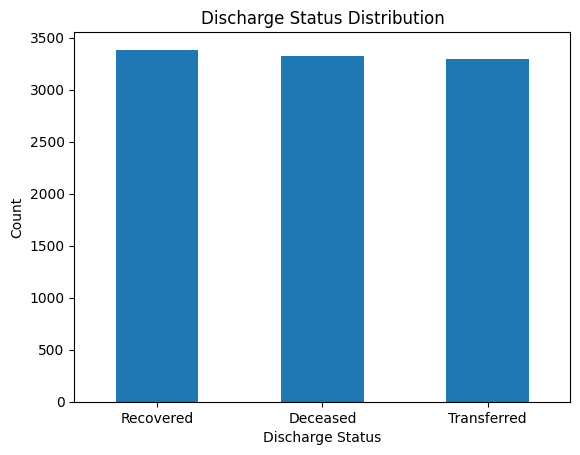

In [19]:
df["discharge_status"].value_counts().plot(kind="bar")
plt.title("Discharge Status Distribution")
plt.xlabel("Discharge Status")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [20]:
df.groupby("readmission")["patient_length_of_stay"].mean()

readmission
0    15.500171
1    15.515451
Name: patient_length_of_stay, dtype: float64

## A quick look at readmission against some features

This is not modelling yet.  
This is only to get a basic sense of whether the target seems to vary across some variables.

In [21]:
df.groupby("readmission")["patient_age"].mean()

readmission
0    47.097644
1    47.545147
Name: patient_age, dtype: float64

In [22]:
df.groupby("readmission")["patient_waittime"].mean()

readmission
0    68.037726
1    67.521729
Name: patient_waittime, dtype: float64

In [23]:
df.groupby("readmission")["patient_sat_score"].mean()

readmission
0    851.022533
1    843.247224
Name: patient_sat_score, dtype: float64

## Note on patient satisfaction score

The patient satisfaction score appears to have values on a much larger scale than a typical survey score.

This suggests that the variable may be synthetic, aggregated, or encoded differently from a standard 1–5 or 1–10 satisfaction rating.

I will inspect its distribution more carefully during preprocessing before deciding whether it should be scaled, transformed, or used as-is.

## Summary

This notebook was used to understand the dataset before modelling.

Main findings from this stage:
- the dataset has 10,000 rows and 26 columns
- there are no missing values or duplicate rows
- the target variable is reasonably balanced
- several identifier columns should be removed later
- the date columns appear to have mixed formats
- simple average comparisons do not show strong separation yet, which means the predictive signal may depend more on feature interactions than on individual variables alone

The next step is to prepare the data for modelling by:
- dropping unnecessary columns
- converting dates carefully
- encoding categorical variables
- creating model-ready features